In [91]:
#import common library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [92]:
df = pd.read_csv("/content/Data_Tingkat_Kemiskinan.csv")

In [93]:
print(df.info())
print(df.head())

print("ini describe yee: ")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Kabupaten_Kota                  514 non-null    object 
 1   Tingkat_Penduduk_Miskin         514 non-null    float64
 2   Rata-rata Lama Sekolah          514 non-null    float64
 3   Indeks Pembangunan Gender       514 non-null    float64
 4   Usia Harapan Hidup              514 non-null    float64
 5   PengeluaranPerKapita            514 non-null    int64  
 6   Harapan Lama Sekolah            514 non-null    float64
 7   Produk Domestik Regional Bruto  514 non-null    float64
 8   Indeks Kemahalan Konstruksi     514 non-null    float64
 9   PengeluaranPerkapita_Rokok      514 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 40.3+ KB
None
  Kabupaten_Kota  Tingkat_Penduduk_Miskin  Rata-rata Lama Sekolah  \
0       Simeulue          

In [94]:
#cek missing
df.isna().sum()

,0
Kabupaten_Kota,0
Tingkat_Penduduk_Miskin,0
Rata-rata Lama Sekolah,0
Indeks Pembangunan Gender,0
Usia Harapan Hidup,0
PengeluaranPerKapita,0
Harapan Lama Sekolah,0
Produk Domestik Regional Bruto,0
Indeks Kemahalan Konstruksi,0
PengeluaranPerkapita_Rokok,0


In [95]:
#cek duplicated
df.duplicated().sum()

np.int64(0)

<Axes: >

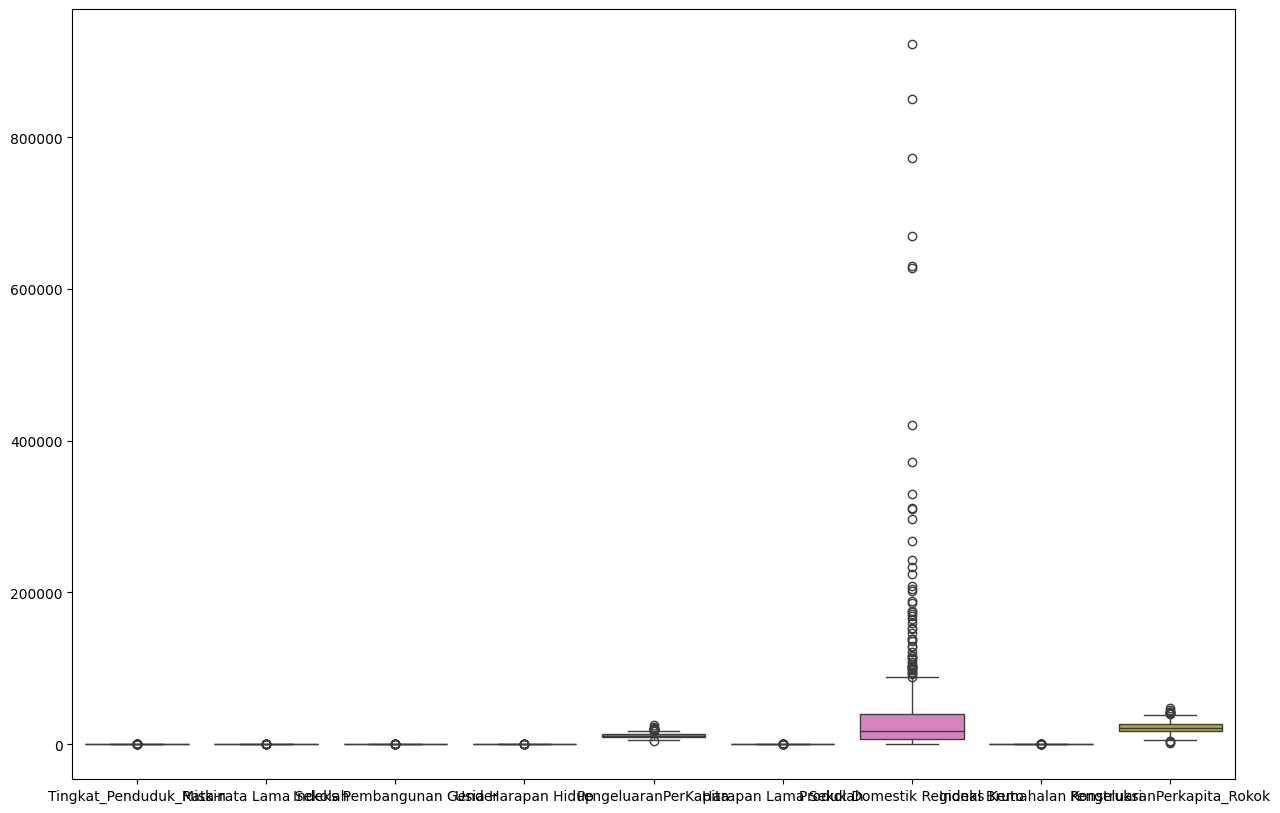

In [96]:
#cek outliers
plt.figure(figsize=(15,10))
sns.boxplot(data=df)

In [97]:
from sklearn.model_selection import train_test_split

feature = df.drop(columns=['Tingkat_Penduduk_Miskin'])
target = df['Tingkat_Penduduk_Miskin']

feature_train, feature_test, target_train, target_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [98]:
# calculate vif score for each column in feature_admit_train
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

# Drop the 'Kabupaten_Kota' column as VIF is for numerical features
X = add_constant(feature_train.drop(columns=['Kabupaten_Kota']))

vif_df = (pd.DataFrame(
            [vif(X.values, i) for i in range(len(X.columns))]
            ,index=X.columns)
            .reset_index())

vif_df.columns = ['feature','vif_score']
vif_df = vif_df.loc[vif_df.feature!='const']
vif_df

,feature,vif_score
1,Rata-rata Lama Sekolah,3.256098
2,Indeks Pembangunan Gender,1.481402
3,Usia Harapan Hidup,1.620914
4,PengeluaranPerKapita,2.812529
5,Harapan Lama Sekolah,2.953565
6,Produk Domestik Regional Bruto,1.452568
7,Indeks Kemahalan Konstruksi,1.425318
8,PengeluaranPerkapita_Rokok,1.117878


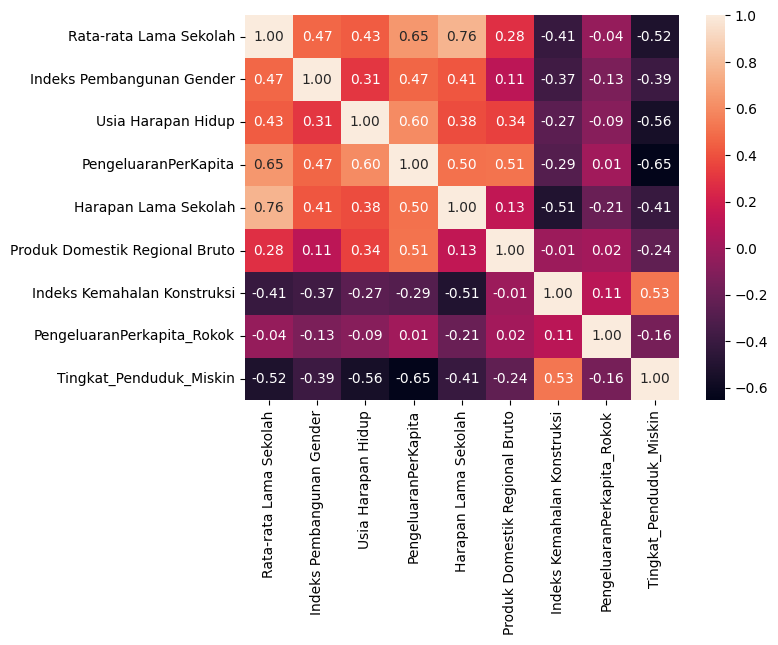

In [99]:
# heatmap correlation
admit_train = pd.concat([feature_train, target_train], axis=1)
# Drop non-numeric columns like 'Kabupaten_Kota' before calculating correlation
corr = admit_train.drop(columns=['Kabupaten_Kota']).corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()

modeling

In [100]:
#patenkan fiturfitur yang dipakai
features = [
    'Usia Harapan Hidup',
    'PengeluaranPerKapita',
]

X = df[features]

In [101]:
#scaling data
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
scaler = MinMaxScaler()
scaler2 = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [102]:
#lihat tampilan data after scaling
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.describe()

,Usia Harapan Hidup,PengeluaranPerKapita
count,514.000000,514.000000
mean,0.651380,0.326013
std,0.150604,0.134464
min,0.000000,0.000000
25%,0.555950,0.240799
50%,0.659414,0.319794
75%,0.756661,0.395678
max,1.000000,1.000000


In [103]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#elbow method for menentukan jumlah cluster terbaik
inertia = []

K_range = range(1, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10 # Add n_init to suppress future warning
    )

    # Use X_scaled instead of feature since feature contains non-numeric column 'Kabupaten_Kota'
    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

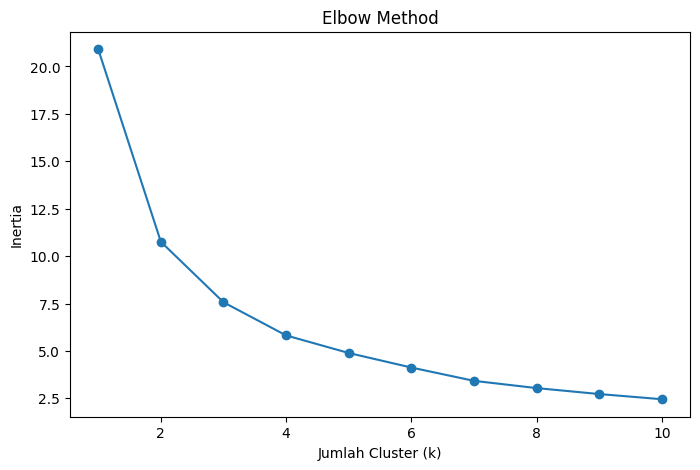

In [104]:
#visualisasi elbow method
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [105]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"k={k}, score={score}")

k=2, score=0.41300701282065916
k=3, score=0.3464542058765498
k=4, score=0.3440857664229553
k=5, score=0.31583154610669256
k=6, score=0.31300601388952626
k=7, score=0.35033854500000733
k=8, score=0.34045841723173714
k=9, score=0.3340277553814272
k=10, score=0.3457444440719463


In [106]:
#membuat model k-means
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

In [107]:
# training + hasil cluster
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [108]:
#lihat hasil clusternya
print(df[['Kabupaten_Kota', 'Cluster']].head())

  Kabupaten_Kota  Cluster
0       Simeulue        1
1   Aceh Singkil        1
2   Aceh Selatan        1
3  Aceh Tenggara        1
4     Aceh Timur        1


In [109]:
#rata-rata tiap cluster
# Exclude 'Kabupaten_Kota' from the columns for which to calculate the mean
cluster_summary = df.groupby('Cluster')[feature.drop(columns=['Kabupaten_Kota']).columns.tolist()].mean()

print(cluster_summary)

         Rata-rata Lama Sekolah  Indeks Pembangunan Gender  \
Cluster                                                      
0                      9.269017                  92.035729   
1                      8.029406                  88.855160   

         Usia Harapan Hidup  PengeluaranPerKapita  Harapan Lama Sekolah  \
Cluster                                                                   
0                 72.626305          12913.966102             13.500271   
1                 67.422420           9443.821918             12.793744   

         Produk Domestik Regional Bruto  Indeks Kemahalan Konstruksi  \
Cluster                                                                
0                          65038.944949                   100.850034   
1                          13216.210594                   111.815068   

         PengeluaranPerkapita_Rokok  
Cluster                              
0                      22249.772881  
1                      21811.378995  


In [110]:
#lihat scorenya
score = silhouette_score(X_scaled, df['Cluster'])
print('Silhouette Score:', score)

Silhouette Score: 0.41300701282065916


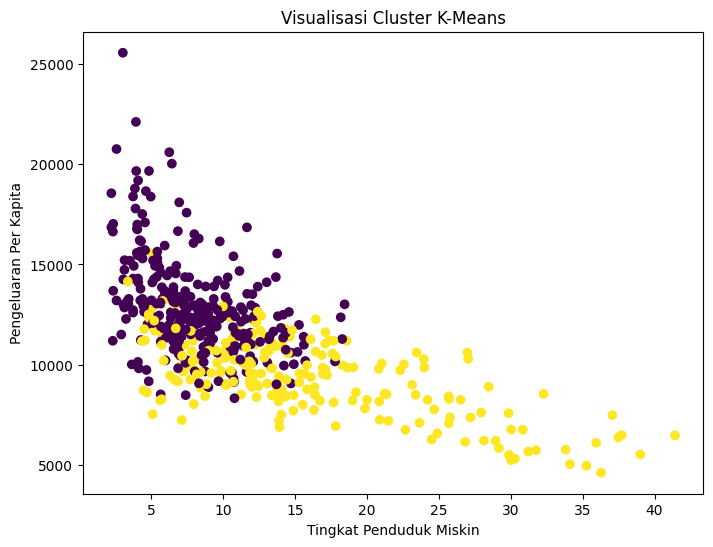

In [111]:
#tampilkan
#visualisasi sederhana
plt.figure(figsize=(8,6))

plt.scatter(
    df['Tingkat_Penduduk_Miskin'],
    df['PengeluaranPerKapita'],
    c=df['Cluster']
)

plt.xlabel('Tingkat Penduduk Miskin')
plt.ylabel('Pengeluaran Per Kapita')
plt.title('Visualisasi Cluster K-Means')

plt.show()